## Agent-Eval Test 1

RETRIEVAL_K = 2

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
RESULTS_FILE = "test_1.json"

In [3]:
# Load the specified or latest file
if RESULTS_FILE:
    result_path = RESULTS_FILE
    with open(result_path, 'r') as f:
        data = json.load(f)
    print(f"Loaded: {RESULTS_FILE}")
    print(f"Timestamp: {data['timestamp']}")
    print(f"Total tests: {data['total_tests']}")
else:
    raise ValueError("No results file available. Run test.py first to generate test results.")

Loaded: test_1.json
Timestamp: 2025-11-22T12:08:54.145530
Total tests: 10


In [4]:
# Show summary metrics
agg = data['aggregate']

print("\nTEST RESULTS")
print("=" * 50)
print(f"Success Rate: {agg['success_rate']:.1%}")
print(f"Passed: {agg['successful_tests']}/{agg['total_tests']}")

if agg.get('rag_tests', 0) > 0:
    print(f"\nRAG Tests: {agg['rag_tests']}")
    print(f"  Avg Context Precision: {agg.get('rag_avg_context_precision', 0):.2f}")
    print(f"  Avg Answer Relevance: {agg.get('rag_avg_answer_relevance', 0):.2f}")

if agg.get('sql_tests', 0) > 0:
    print(f"\nSQL Tests: {agg['sql_tests']}")
    print(f"  Success Rate: {agg.get('sql_success_rate', 0):.1%}")



TEST RESULTS
Success Rate: 100.0%
Passed: 10/10

RAG Tests: 6
  Avg Context Precision: 0.94
  Avg Answer Relevance: 0.82

SQL Tests: 4
  Success Rate: 100.0%


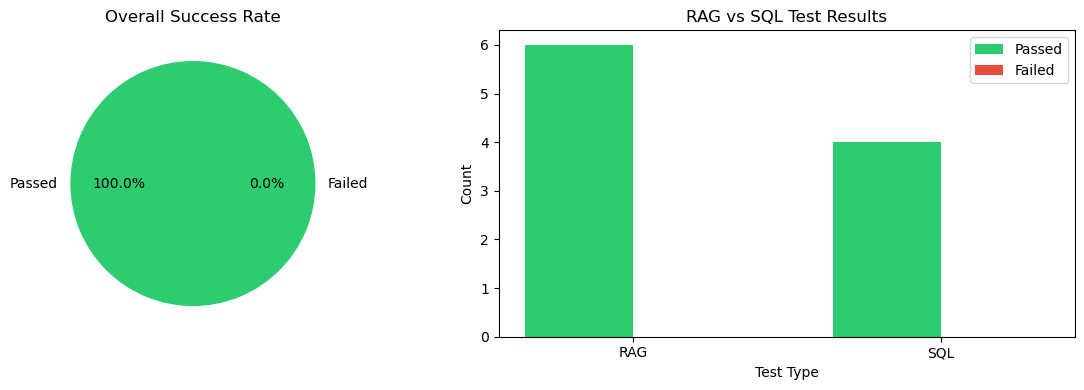

In [5]:
# Combined visualizations for RAG and SQL results
df = pd.DataFrame(data['results'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall success rate pie chart
passed = agg['successful_tests']
failed = agg['total_tests'] - passed
axes[0].pie([passed, failed], labels=['Passed', 'Failed'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Overall Success Rate')

# RAG vs SQL comparison
rag_tests = df[df['type'] == 'rag']
sql_tests = df[df['type'] == 'sql']

if len(rag_tests) > 0 and len(sql_tests) > 0:
    rag_passed = rag_tests['success'].sum()
    rag_failed = len(rag_tests) - rag_passed
    sql_passed = sql_tests['success'].sum()
    sql_failed = len(sql_tests) - sql_passed
    
    categories = ['RAG', 'SQL']
    passed_counts = [rag_passed, sql_passed]
    failed_counts = [rag_failed, sql_failed]
    
    x = range(len(categories))
    width = 0.35
    
    axes[1].bar([i - width/2 for i in x], passed_counts, width, label='Passed', color='#2ecc71')
    axes[1].bar([i + width/2 for i in x], failed_counts, width, label='Failed', color='#e74c3c')
    axes[1].set_xlabel('Test Type')
    axes[1].set_ylabel('Count')
    axes[1].set_title('RAG vs SQL Test Results')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(categories)
    axes[1].legend()
elif len(rag_tests) > 0:
    rag_passed = rag_tests['success'].sum()
    rag_failed = len(rag_tests) - rag_passed
    axes[1].bar(['RAG'], [rag_passed], label='Passed', color='#2ecc71')
    axes[1].bar(['RAG'], [rag_failed], bottom=[rag_passed], label='Failed', color='#e74c3c')
    axes[1].set_title('RAG Test Results')
    axes[1].legend()
elif len(sql_tests) > 0:
    sql_passed = sql_tests['success'].sum()
    sql_failed = len(sql_tests) - sql_passed
    axes[1].bar(['SQL'], [sql_passed], label='Passed', color='#2ecc71')
    axes[1].bar(['SQL'], [sql_failed], bottom=[sql_passed], label='Failed', color='#e74c3c')
    axes[1].set_title('SQL Test Results')
    axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
# Show combined RAG and SQL test results
df = pd.DataFrame(data['results'])

print("\nDETAILED TEST RESULTS")
print("=" * 50)

# RAG tests
rag_tests = df[df['type'] == 'rag']
if len(rag_tests) > 0:
    print("\nRAG TESTS:")
    print("-" * 50)
    for _, row in rag_tests.iterrows():
        status = "✓ PASS" if row['success'] else "✗ FAIL"
        print(f"\n{row['test_id']}: {status}")
        print(f"  Question: {row['question']}")
        if 'metrics' in row:
            metrics = row['metrics']
            if 'context_precision' in metrics:
                print(f"  Context Precision: {metrics['context_precision']:.2f}")
            if 'answer_relevance' in metrics:
                print(f"  Answer Relevance: {metrics['answer_relevance']:.2f}")
        if 'error' in row and row['error']:
            print(f"  Error: {row['error']}")

# SQL tests
sql_tests = df[df['type'] == 'sql']
if len(sql_tests) > 0:
    print("\nSQL TESTS:")
    print("-" * 50)
    for _, row in sql_tests.iterrows():
        status = "✓ PASS" if row['success'] else "✗ FAIL"
        print(f"\n{row['test_id']}: {status}")
        print(f"  Question: {row['question']}")
        if 'metrics' in row and 'result_count' in row['metrics']:
            print(f"  Results: {row['metrics']['result_count']} row(s)")
        if 'sql_error' in row and row['sql_error']:
            print(f"  Error: {row['sql_error']}")
        if 'sql_results_sample' in row and row['sql_results_sample']:
            print(f"  Sample: {row['sql_results_sample'][:200]}...")
print()


DETAILED TEST RESULTS

RAG TESTS:
--------------------------------------------------

rag_001: ✓ PASS
  Question: What is AI Agent Insure?
  Context Precision: 1.00
  Answer Relevance: 0.80

rag_002: ✓ PASS
  Question: What does Agentic AI Liability Insurance cover?
  Context Precision: 1.00
  Answer Relevance: 0.90

rag_003: ✓ PASS
  Question: What is Model and Data Security Insurance?
  Context Precision: 0.67
  Answer Relevance: 0.80

rag_004: ✓ PASS
  Question: What is Intellectual Property and Output Protection?
  Context Precision: 1.00
  Answer Relevance: 0.90

rag_005: ✓ PASS
  Question: What does Compliance and Regulatory Shield cover?
  Context Precision: 1.00
  Answer Relevance: 0.60

rag_006: ✓ PASS
  Question: What is the difference between Agentic AI Liability Insurance and Model and Data Security Insurance?
  Context Precision: 1.00
  Answer Relevance: 0.90

SQL TESTS:
--------------------------------------------------

sql_001: ✓ PASS
  Question: How many insureds are 

In [7]:
# Show failed tests
df = pd.DataFrame(data['results'])
failed_tests = df[df['success'] == False]

if len(failed_tests) > 0:
    print(f"\nFAILED TESTS ({len(failed_tests)}):")
    print("=" * 50)
    for _, row in failed_tests.iterrows():
        print(f"\n{row['test_id']}")
        print(f"  Type: {row['type']}")
        if 'error' in row:
            print(f"  Error: {row['error']}")
        elif 'sql_error' in row and row['sql_error']:
            print(f"  SQL Error: {row['sql_error']}")
else:
    print("\n✓ All tests passed!")



✓ All tests passed!
